In [1]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
import json
import time
import os
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset

In [2]:
# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Hyperparameters
CONFIG = {
    'model_name': 'CustomCNN',
    'batch_size': 32,
    'learning_rate': 0.001,
    'epochs': 200,
    'image_size': 224,
    'patience': 5  # Early stopping patience
}

print(f"Model: {CONFIG['model_name']}")
print(f"Batch Size: {CONFIG['batch_size']}")
print(f"Learning Rate: {CONFIG['learning_rate']}")
print(f"Epochs: {CONFIG['epochs']}")

Device: cuda
Model: CustomCNN
Batch Size: 32
Learning Rate: 0.001
Epochs: 200


In [3]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

class PM25Dataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None, class_to_idx=None):
        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform

        # Remove missing images
        self.df = self.df[self.df['filename'].apply(
            lambda x: os.path.exists(os.path.join(image_dir, x))
        )].reset_index(drop=True)

        # SORTED class order
        if class_to_idx is None:
            self.classes = sorted(
                self.df['pm25_bin'].unique(),
                key=lambda x: int(x.split('\u2013')[0])  # EN DASH
            )
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        else:
            self.class_to_idx = class_to_idx
            self.classes = list(class_to_idx.keys())

        # Create labels AFTER mapping
        self.df['label'] = self.df['pm25_bin'].map(self.class_to_idx)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['filename'])
        image = Image.open(img_path).convert("RGB")
        label = row['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:
# Data Loading and Preprocessing with Augmentation
import torch
from torchvision import transforms

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Loading datasets...")

# Train dataset
train_dataset = PM25Dataset(
    "/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv",
    "/kaggle/input/datasets/deadcardassian/pm25vision/train/images",
    transform=train_transform
)

# Test dataset (reuse mapping)
test_dataset = PM25Dataset(
    "/kaggle/input/datasets/deadcardassian/pm25vision/test/metadata.csv",
    "/kaggle/input/datasets/deadcardassian/pm25vision/test/images",
    transform=val_transform,
    class_to_idx=train_dataset.class_to_idx
)

# Define these properly
class_names = train_dataset.classes
num_classes = len(class_names)

# DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2
)

print(f"\nDataset Info:")
print(f"  Classes: {class_names}")
print(f"  Num Classes: {num_classes}")
print(f"  Train Samples: {len(train_dataset)}")
print(f"  Test Samples: {len(test_dataset)}")

Loading datasets...

Dataset Info:
  Classes: ['0–50', '51–100', '101–150', '151–200', '201–300', '301–600']
  Num Classes: 6
  Train Samples: 8298
  Test Samples: 2921


In [5]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        self._init_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)

In [6]:
model = CustomCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
# Create Custom CNN Model
print(f"\nCreating {CONFIG['model_name']} model...")
model = CustomCNN(num_classes=num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"Model moved to {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Creating CustomCNN model...
Model moved to cuda
Total parameters: 1,703,430
Trainable parameters: 1,703,430


In [9]:
# Training Loop
print(f"\n{'='*70}")
print(f"Training {CONFIG['model_name']}")
print(f"{'='*70}")

start_train = time.time()
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(CONFIG['epochs']):
    # ── Training Phase ────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    batch_count = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
        batch_count += 1

    avg_train_loss = running_loss / batch_count
    train_accuracy = train_correct / train_total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # ── Validation Phase ──────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    batch_count = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
            batch_count += 1

    avg_val_loss = val_loss / batch_count
    val_accuracy = val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(avg_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{CONFIG['epochs']} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

train_time = time.time() - start_train
print(f"\nTraining completed in {train_time:.2f} seconds")
print(f"{'='*70}")


Training CustomCNN
Epoch  1/200 | Train Loss: 1.6964 | Val Loss: 1.6583 | Train Acc: 0.2373 | Val Acc: 0.2592
Epoch  5/200 | Train Loss: 1.6302 | Val Loss: 1.6302 | Train Acc: 0.2716 | Val Acc: 0.2879
Epoch 10/200 | Train Loss: 1.5666 | Val Loss: 1.6971 | Train Acc: 0.3127 | Val Acc: 0.2831
Epoch 15/200 | Train Loss: 1.5045 | Val Loss: 1.5504 | Train Acc: 0.3535 | Val Acc: 0.3338
Epoch 20/200 | Train Loss: 1.4701 | Val Loss: 1.5313 | Train Acc: 0.3643 | Val Acc: 0.3554
Epoch 25/200 | Train Loss: 1.4381 | Val Loss: 1.4997 | Train Acc: 0.3820 | Val Acc: 0.3759
Epoch 30/200 | Train Loss: 1.3880 | Val Loss: 1.4749 | Train Acc: 0.3948 | Val Acc: 0.3851
Epoch 35/200 | Train Loss: 1.3667 | Val Loss: 1.4914 | Train Acc: 0.4107 | Val Acc: 0.3687
Epoch 40/200 | Train Loss: 1.3427 | Val Loss: 1.4640 | Train Acc: 0.4172 | Val Acc: 0.3903
Epoch 45/200 | Train Loss: 1.3255 | Val Loss: 1.4845 | Train Acc: 0.4255 | Val Acc: 0.3875
Epoch 50/200 | Train Loss: 1.3257 | Val Loss: 1.4713 | Train Acc: 0.43

In [10]:
# Evaluation
print(f"\n{'='*70}")
print(f"Evaluating {CONFIG['model_name']}")
print(f"{'='*70}")

model.eval()
y_true, y_pred, y_probs = [], [], []
start_test = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

test_time = time.time() - start_test

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

print(f"Evaluation completed in {test_time:.2f} seconds")


Evaluating CustomCNN
Evaluation completed in 20.29 seconds


In [11]:
# Calculate Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
cm = confusion_matrix(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_probs, multi_class='ovr')
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Print Results
print(f"\n{'='*70}")
print(f"Results: {CONFIG['model_name']}")
print(f"{'='*70}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC:       {auc_score:.4f}")
print(f"\nTiming:")
print(f"  Train Time: {train_time:.2f}s")
print(f"  Test Time:  {test_time:.2f}s")
print(f"\nClass-wise Accuracy:")
for i, acc_val in enumerate(class_accuracy):
    print(f"  {class_names[i]:10s}: {acc_val:.4f}")
print(f"{'='*70}")


Results: CustomCNN
Accuracy:  0.3841
Precision: 0.3305
Recall:    0.3084
F1-Score:  0.2904
AUC:       0.7458

Timing:
  Train Time: 18160.94s
  Test Time:  20.29s

Class-wise Accuracy:
  0–50      : 0.6238
  51–100    : 0.2175
  101–150   : 0.3349
  151–200   : 0.5841
  201–300   : 0.0109
  301–600   : 0.0794


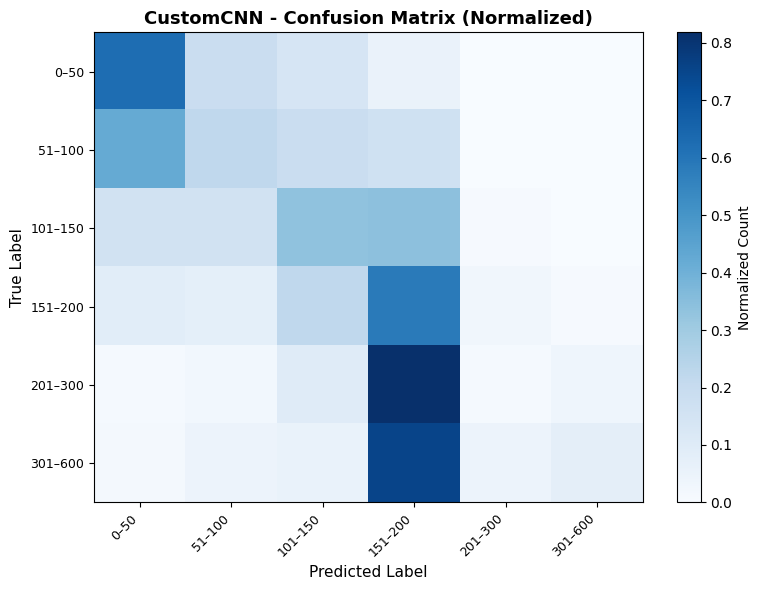

Confusion matrix saved as 'customcnn_confusion_matrix.png'


In [12]:
# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax.set_title(f'{CONFIG["model_name"]} - Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(class_names, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Count', fontsize=10)

plt.tight_layout()
plt.savefig('customcnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'customcnn_confusion_matrix.png'")

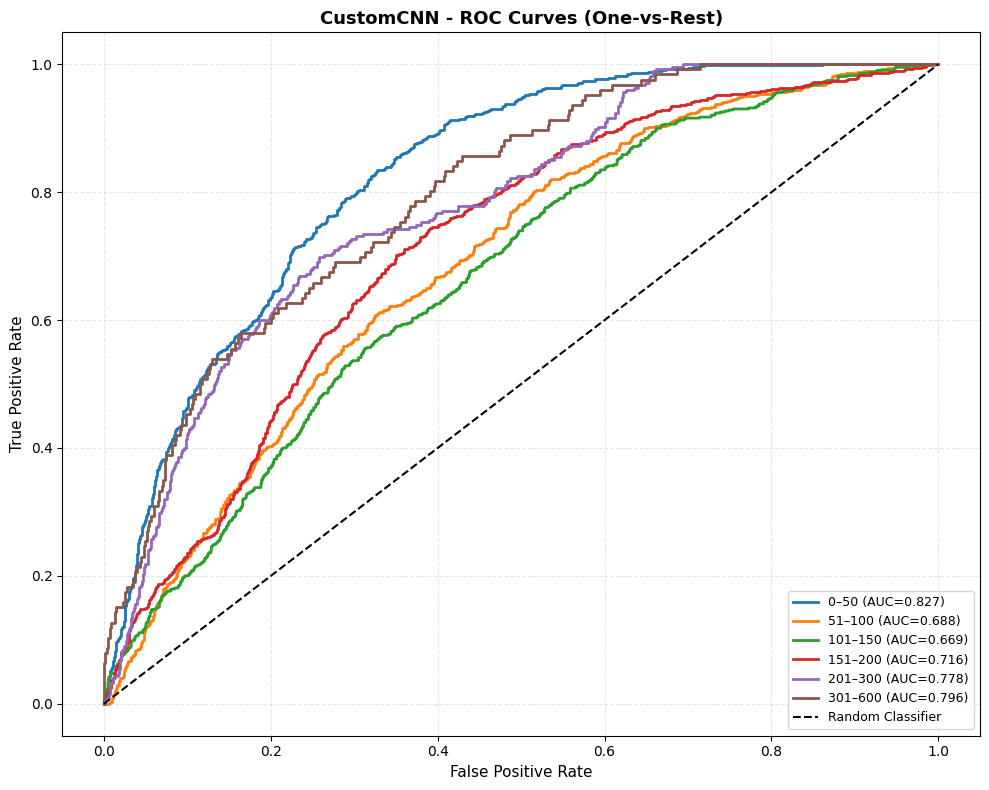

ROC curves saved as 'customcnn_roc_curves.png'


In [13]:
# Plot ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for class_idx in range(num_classes):
    y_true_binary = (y_true == class_idx).astype(int)
    y_probs_class = y_probs[:, class_idx]

    fpr, tpr, _ = roc_curve(y_true_binary, y_probs_class)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f'{class_names[class_idx]} (AUC={roc_auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f'{CONFIG["model_name"]} - ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('customcnn_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC curves saved as 'customcnn_roc_curves.png'")

In [14]:
# Save Results
results = {
    'model': CONFIG['model_name'],
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'auc': float(auc_score),
    'train_time': float(train_time),
    'test_time': float(test_time),
    'epochs': CONFIG['epochs'],
    'batch_size': CONFIG['batch_size'],
    'learning_rate': CONFIG['learning_rate'],
    'class_accuracy': {class_names[i]: float(class_accuracy[i]) for i in range(num_classes)},
    'confusion_matrix': cm.tolist()
}

# Save to JSON
with open('customcnn_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print("Results saved to 'customcnn_results.json'")

# Save confusion matrix to CSV
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv('customcnn_confusion_matrix.csv')
print("Confusion matrix saved to 'customcnn_confusion_matrix.csv'")

Results saved to 'customcnn_results.json'
Confusion matrix saved to 'customcnn_confusion_matrix.csv'


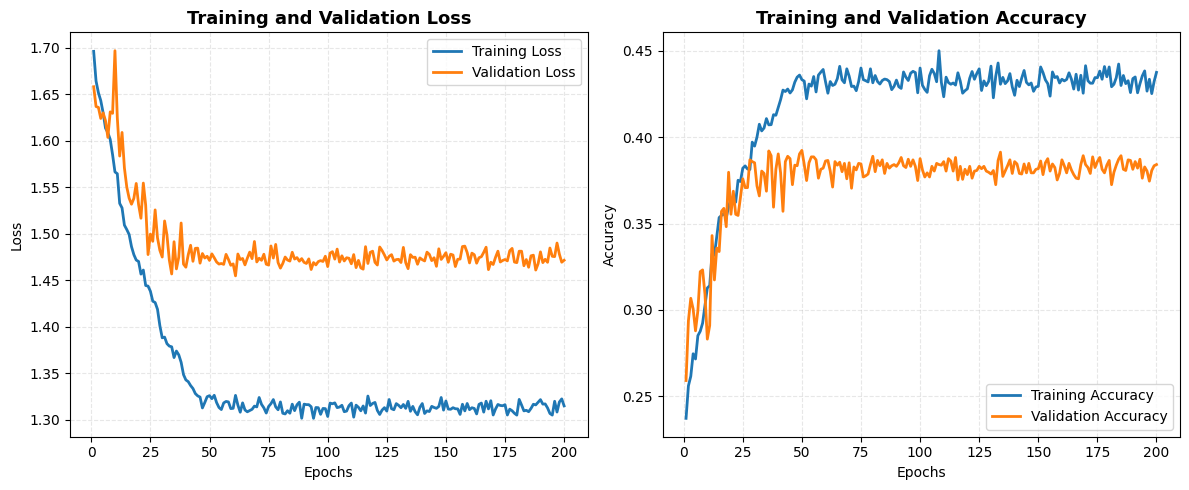

In [15]:
# Plot Learning Curves
def training_curves(train_loss_history, val_loss_history, train_acc_history, val_acc_history):
    epochs = range(1, len(train_loss_history) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss_history, label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss_history, label='Validation Loss', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=13, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3, linestyle='--')

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc_history, label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc_history, label='Validation Accuracy', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=13, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig('customcnn_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

# Create learning curves
training_curves(train_losses, val_losses, train_accuracies, val_accuracies)